In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

from data.parsers.highd_parser import *
from data.feature_engineering.platoon_extractor import *
from data.feature_engineering.profile_generator import *

In [2]:
tracks_df, meta_df = load_all_recordings()

print(tracks_df.shape)
print(meta_df.shape)

Loading recording 01
Loading recording 02
Loading recording 03
Loading recording 04
Loading recording 05
Loading recording 06
Loading recording 07
Loading recording 08
Loading recording 09
Loading recording 10
Loading recording 11
Loading recording 12
Loading recording 13
Loading recording 14
Loading recording 15
Loading recording 16
Loading recording 17
Loading recording 18
Loading recording 19
Loading recording 20
Loading recording 21
Loading recording 22
Loading recording 23
Loading recording 24
Loading recording 25
Loading recording 26
Loading recording 27
Loading recording 28
Loading recording 29
Loading recording 30
Loading recording 31
Loading recording 32
Loading recording 33
Loading recording 34
Loading recording 35
Loading recording 36
Loading recording 37
Loading recording 38
Loading recording 39
Loading recording 40
Loading recording 41
Loading recording 42
Loading recording 43
Loading recording 44
Loading recording 45
Loading recording 46
Loading recording 47
Loading recor

In [3]:
truck_tracks, truck_meta = filter_trucks(tracks_df, meta_df)
truck_tracks = keep_longitudinal_columns(truck_tracks)
truck_tracks.head()

,recordingId,frame,id,laneId,precedingId,followingId,x,xVelocity,xAcceleration,dhw,thw,ttc
0,1,1,1,5,0,3,362.26,40.85,0.30,0.0,0.0,0.0
1,1,2,1,5,0,14,363.73,40.87,0.30,0.0,0.0,0.0
2,1,3,1,5,0,14,365.27,40.88,0.31,0.0,0.0,0.0
3,1,4,1,5,0,14,366.83,40.89,0.32,0.0,0.0,0.0
4,1,5,1,5,0,14,368.42,40.90,0.32,0.0,0.0,0.0


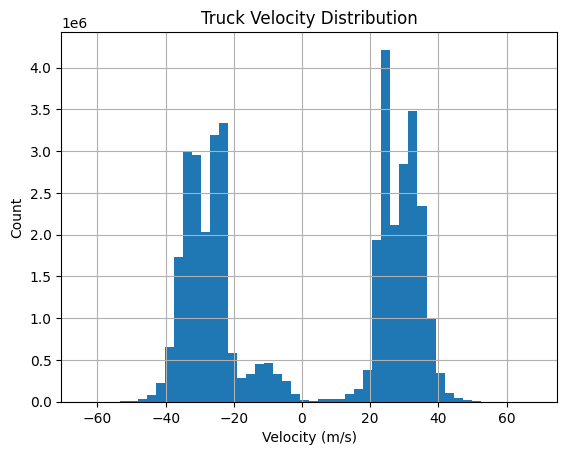

In [4]:
truck_tracks["xVelocity"].hist(bins=50)
plt.title("Truck Velocity Distribution")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Count")
plt.show()

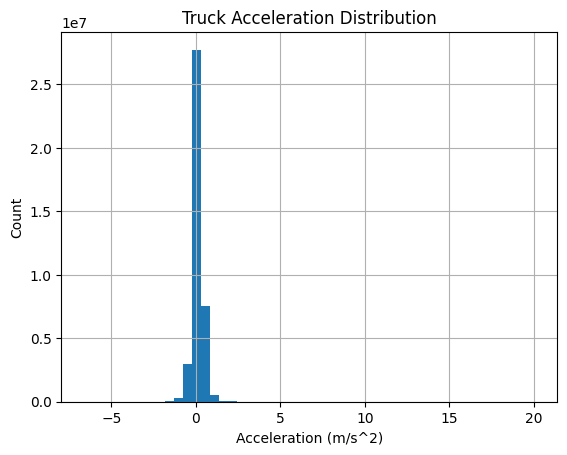

In [5]:
truck_tracks["xAcceleration"].hist(bins=50)
plt.title("Truck Acceleration Distribution")
plt.xlabel("Acceleration (m/s^2)")
plt.ylabel("Count")
plt.show()

In [6]:
sequences = extract_following_sequences(truck_tracks)
print("Number of sequences", len(sequences))

Number of sequences 4372


In [7]:
summary_df = build_sequence_summary_dataframe(sequences)
summary_df.head()

,leader_id,follower_id,duration_frames,convergence_time,initial_spacing,steady_spacing,min_spacing,max_spacing,spacing_std,initial_velocity,...,relative_acceleration_std,mean_thw,std_thw,min_thw,max_thw,velocity_oscillation,accel_oscillation,spacing_oscillation,rms_acceleration,rms_jerk
0,18,9,272,8.48,26.52,38.0236,26.27,39.21,4.221411,33.24,...,NaN,0.949191,0.121628,0.79,1.14,0.332880,0.203108,4.221411,0.223069,0.146967
1,14,11,354,0.80,23.06,20.2028,19.93,23.06,0.570050,23.51,...,NaN,0.911751,0.019752,0.87,0.98,0.226922,0.120427,0.570050,0.129303,0.123222
2,17,12,369,10.32,49.83,56.6224,25.49,58.52,6.942043,36.39,...,NaN,2.140894,0.423902,0.72,2.39,3.760385,0.139829,6.942043,0.248432,4.856756
3,19,13,423,NaN,25.49,75.4496,21.41,87.12,22.047608,25.05,...,NaN,1.838842,0.906174,0.88,3.57,0.244711,0.072311,22.047608,0.099974,1.367471
4,26,13,401,13.32,21.98,20.8292,17.85,24.02,1.365232,31.57,...,NaN,0.647282,0.066565,0.54,0.74,1.712713,0.329119,1.365232,0.373705,10.880235


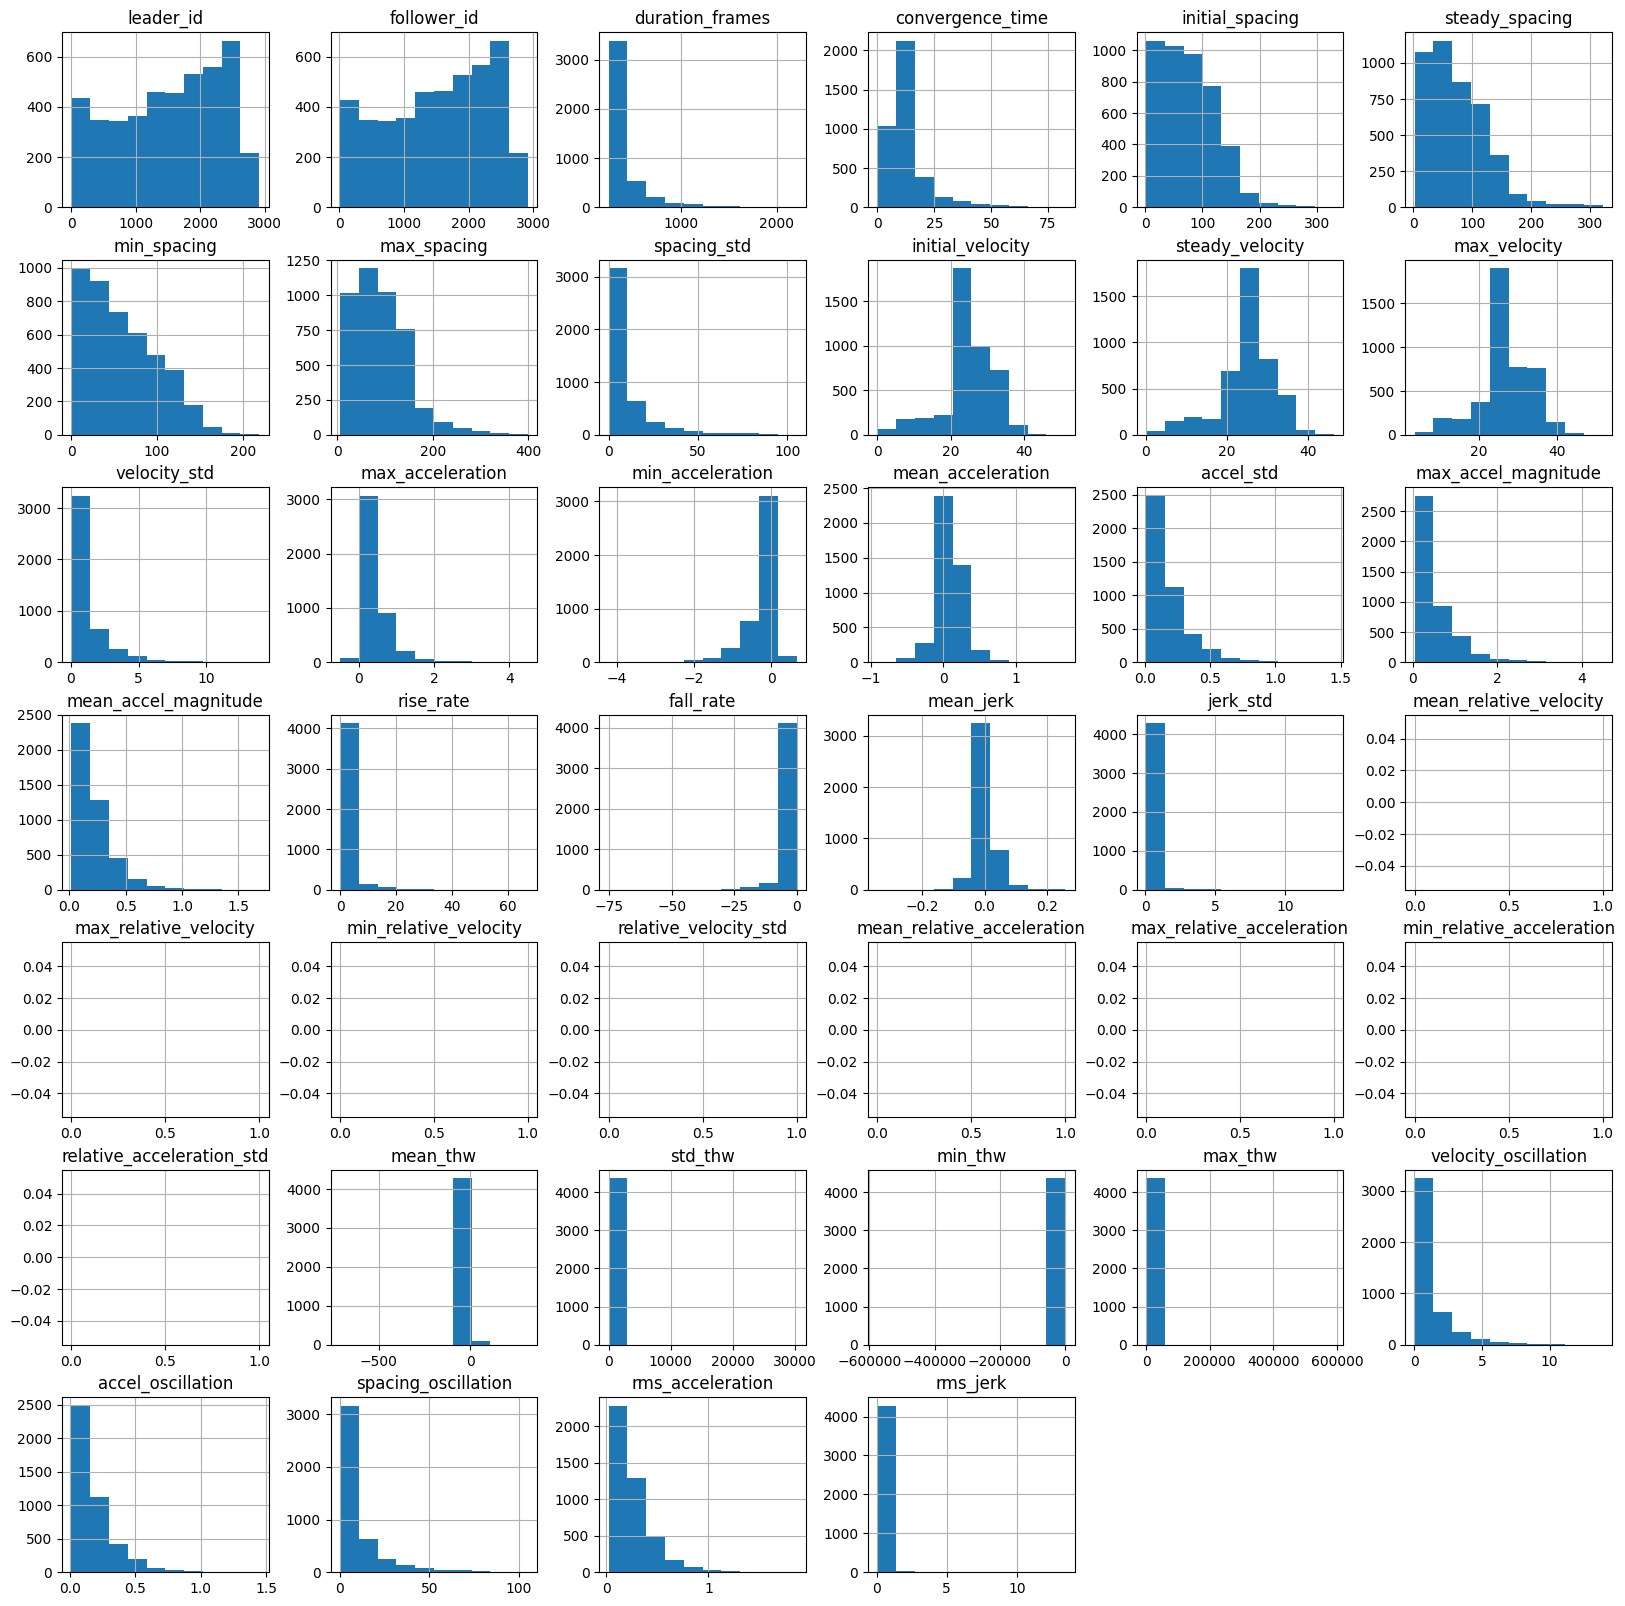

,leader_id,follower_id,duration_frames,convergence_time,initial_spacing,steady_spacing,min_spacing,max_spacing,spacing_std,initial_velocity,...,relative_acceleration_std,mean_thw,std_thw,min_thw,max_thw,velocity_oscillation,accel_oscillation,spacing_oscillation,rms_acceleration,rms_jerk
leader_id,1.000000,0.999938,-0.003654,-0.026732,-0.220525,-0.252598,-0.209803,-0.272133,-0.160337,0.131604,...,NaN,-0.013031,-0.004394,0.010454,0.005798,0.003609,0.123600,-0.160337,0.129264,-0.068961
follower_id,0.999938,1.000000,-0.003729,-0.026706,-0.216018,-0.249466,-0.205726,-0.268670,-0.159648,0.129896,...,NaN,-0.013513,-0.004620,0.010051,0.004842,0.002909,0.122148,-0.159648,0.128021,-0.069731
duration_frames,-0.003654,-0.003729,1.000000,0.919737,-0.312935,-0.225700,-0.417342,-0.160390,0.174484,-0.496849,...,NaN,-0.023404,0.071636,-0.071288,0.061491,0.544743,0.368998,0.174484,0.242350,0.155947
convergence_time,-0.026732,-0.026706,0.919737,1.000000,-0.261109,-0.205924,-0.396814,-0.114160,0.275491,-0.437193,...,NaN,-0.022707,0.065062,-0.061243,0.058325,0.584803,0.398300,0.275491,0.313619,0.165486
initial_spacing,-0.220525,-0.216018,-0.312935,-0.261109,1.000000,0.672754,0.849018,0.804610,0.265586,0.231434,...,NaN,0.145155,-0.023101,0.030396,-0.007932,-0.138735,-0.324299,0.265586,-0.248298,-0.039371
steady_spacing,-0.252598,-0.249466,-0.225700,-0.205924,0.672754,1.000000,0.792203,0.873390,0.461968,0.092349,...,NaN,0.110298,-0.045918,0.042586,-0.041346,-0.049807,-0.376690,0.461968,-0.354122,0.015706
min_spacing,-0.209803,-0.205726,-0.417342,-0.396814,0.849018,0.792203,1.000000,0.698749,-0.011343,0.121505,...,NaN,0.123949,-0.055108,0.051710,-0.048342,-0.326862,-0.486368,-0.011343,-0.442584,-0.099284
max_spacing,-0.272133,-0.268670,-0.160390,-0.114160,0.804610,0.873390,0.698749,1.000000,0.679794,0.181823,...,NaN,0.130078,-0.021820,0.027094,-0.010006,0.084709,-0.267687,0.679794,-0.217802,0.071420
spacing_std,-0.160337,-0.159648,0.174484,0.275491,0.265586,0.461968,-0.011343,0.679794,1.000000,0.134736,...,NaN,0.058431,0.020031,-0.010169,0.028994,0.426220,0.094883,1.000000,0.115733,0.200760
initial_velocity,0.131604,0.129896,-0.496849,-0.437193,0.231434,0.092349,0.121505,0.181823,0.134736,1.000000,...,NaN,0.011639,-0.097413,0.098416,-0.070688,-0.111639,-0.138958,0.134736,-0.029703,0.086059


In [8]:
summary_df.hist(figsize=(20,20))
plt.show()
summary_df.describe()
summary_df.corr(numeric_only=True)

<Axes: >

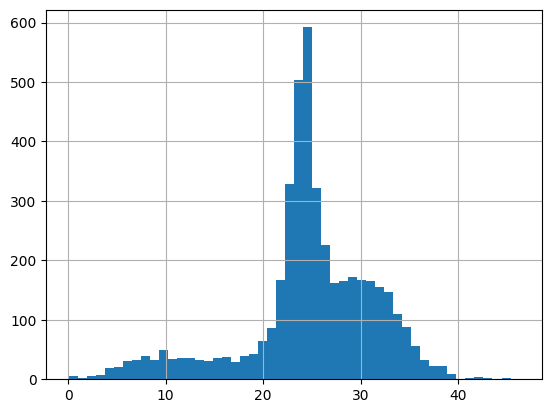

In [9]:
summary_df["steady_velocity"].hist(bins=50)

<Axes: >

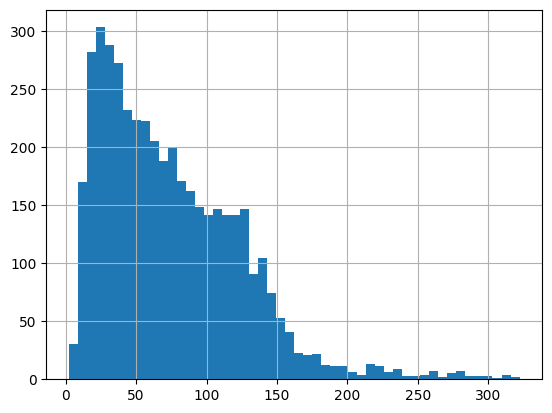

In [10]:
summary_df["steady_spacing"].hist(bins=50)

<Axes: >

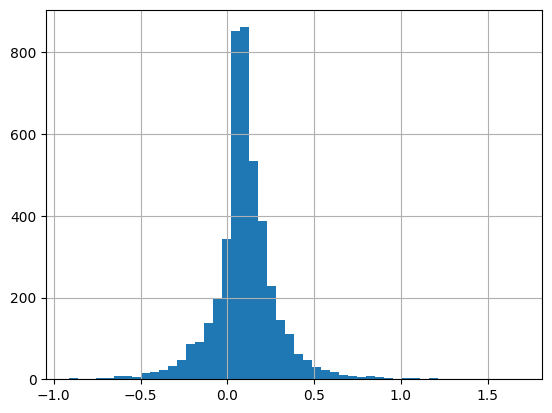

In [11]:
summary_df["mean_acceleration"].hist(bins=50)


<Axes: >

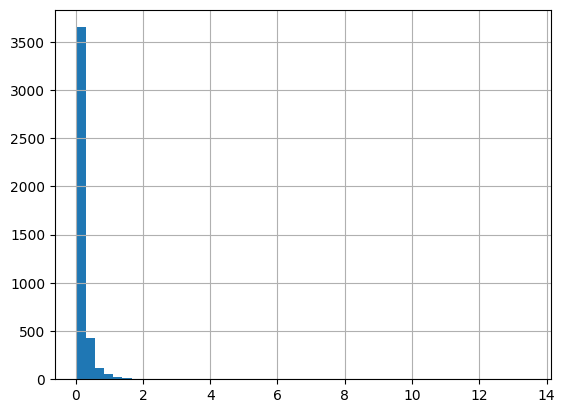

In [12]:
summary_df["rms_jerk"].hist(bins=50)

In [13]:
print(summary_df.dtypes)
print(summary_df["steady_velocity"].head())

leader_id                       int64
follower_id                     int64
duration_frames                 int64
convergence_time              float64
initial_spacing               float64
steady_spacing                float64
min_spacing                   float64
max_spacing                   float64
spacing_std                   float64
initial_velocity              float64
steady_velocity               float64
max_velocity                  float64
velocity_std                  float64
max_acceleration              float64
min_acceleration              float64
mean_acceleration             float64
accel_std                     float64
max_accel_magnitude           float64
mean_accel_magnitude          float64
rise_rate                     float64
fall_rate                     float64
mean_jerk                     float64
jerk_std                      float64
mean_relative_velocity        float64
max_relative_velocity         float64
min_relative_velocity         float64
relative_vel

In [14]:
profiles_df = generate_all_profiles(summary_df)
profiles_df

Quantile thresholds:
  v25: 22.837
  v75: 29.078
  s25: 34.643
  s50: 65.014
  s75: 106.237
  j75: 0.245
  j90: 0.438
  a75: 0.680
  a90: 1.070

Sequences captured: 2898 / 4372 (66.3%)


,profile,num_sequences,cruise_speed,steady_spacing,initial_spacing,rise_rate,fall_rate,convergence_time,velocity_std,spacing_std,accel_std,jerk_std
0,Conservative,295,20.713437,25.0,40.0,0.330508,-0.364407,10.689151,0.626935,7.445023,0.105524,0.118141
1,Normal Highway,979,25.270367,15.0,25.0,0.347804,-0.377681,9.526384,0.612351,6.011045,0.099107,0.120524
2,Aggressive Merge,763,23.027864,10.0,20.0,4.951180,-5.634010,20.628532,2.947463,18.886229,0.408641,0.895269
3,Congested,452,12.374195,8.0,15.0,0.976770,-0.848451,22.920376,2.409009,7.096929,0.416998,0.270543
4,Deceleration Event,409,29.748942,12.0,30.0,3.955379,-11.714548,19.063458,2.653982,25.619294,0.228934,1.235639


In [15]:
print(summary_df[["steady_velocity", "steady_spacing"]].describe())
#check overlap between profiles
total = profiles_df["num_sequences"].sum()
print(f"Total sequences across profiles: {total}")
print(f"Total in summary_df: {len(summary_df)}")

       steady_velocity  steady_spacing
count      4372.000000     4372.000000
mean         24.792997       74.737130
std           6.750257       50.106182
min           0.063800        2.138400
25%          22.836550       34.642550
50%          24.794200       65.014000
75%          29.078100      106.237250
max          46.285400      322.083600
Total sequences across profiles: 2898
Total in summary_df: 4372


In [16]:
print(summary_df["steady_velocity"].describe())
print(summary_df["steady_spacing"].describe())
print(summary_df["max_accel_magnitude"].describe())
print(summary_df["rms_jerk"].describe())

count    4372.000000
mean       24.792997
std         6.750257
min         0.063800
25%        22.836550
50%        24.794200
75%        29.078100
max        46.285400
Name: steady_velocity, dtype: float64
count    4372.000000
mean       74.737130
std        50.106182
min         2.138400
25%        34.642550
50%        65.014000
75%       106.237250
max       322.083600
Name: steady_spacing, dtype: float64
count    4372.000000
mean        0.529037
std         0.468369
min         0.050000
25%         0.220000
50%         0.380000
75%         0.680000
max         4.490000
Name: max_accel_magnitude, dtype: float64
count    4372.000000
mean        0.283307
std         0.649594
min         0.050555
25%         0.106507
50%         0.147882
75%         0.244851
max        13.458022
Name: rms_jerk, dtype: float64
